### Coursework Question 1

In [113]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.special import logsumexp
from scipy.special import gamma

#### Import the data

Import and plot the given dataset:

In [148]:
data = np.genfromtxt("data.csv")

In [149]:
y = data[:1000]

Text(0, 0.5, 'y')

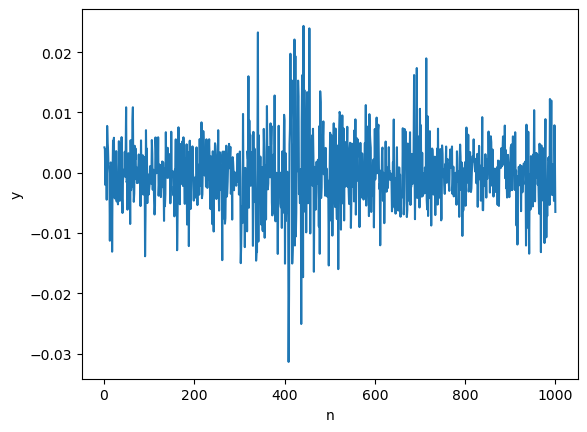

In [150]:
timesteps = np.arange(1,len(y)+1)
plt.plot(timesteps,y)
plt.xlabel("n")
plt.ylabel("y")

#### SIR Particle Filter

In this case, $f(x_n|x_{n-1}) = N(\rho x_{n-1}, \sigma^2)$, and $g(y_n|x_n) = N(0, \beta^2 \exp(\frac{x_n}{2})^2)$

Functions for SIR:

In [9]:
def log_f(x,x_prev,rho,sigma2):

    mean = rho*x_prev
    var = sigma2
    
    valf = -1/2*np.log(2*np.pi*var) - 1/(2*var)*(x-mean)**2
    return valf

In [10]:
def log_g(x,y,beta2):

    mean = 0
    var = beta2*np.exp(x/2)**2
    
    valg = -1/2*np.log(2*np.pi*var) - 1/(2*var)*(y-mean)**2
    return valg

In [11]:
def prop_mean_var(y,x_prev,rho,sigma2):

    S = sigma2
    m = rho*x_prev

    return m,S

In [12]:
def log_q(x,m,S):

    val = -1/2*np.log(2*np.pi*S) - 1/(2*S)*(x-m)**2
    return val

In [13]:
def resample(omega, X, rng):

    # Number of particles
    N = len(X[:,0])

    # Sample offspring from a multinomial distribution with probabilities equal to weights omega
    copies = stats.multinomial.rvs(N,omega,random_state=rng)

    new_X = np.zeros(X.shape)

    # Make new particles by copying each old particle a number of times equal to 'copies'
    k = 0
    for i in range(N):
        if copies[i]>0:
            for _ in range(copies[i]):
                new_X[k,:] = X[i,:]
                k = k+1

    return new_X

In [139]:
def SIR(y,rho,sigma2,beta2,N,rng):

    # Get the full length of the sequence
    T = len(y)

    # Set array to store the particle history and unnormalised weights at each time step
    X = np.zeros((N,T))
    unnormalised_weights = np.zeros((N,T))

    # TIME 0
    # Sample from initial proposal (N(0,0.1^2))
    X[:,0] = stats.norm.rvs(loc=0,scale=0.1,size=N,random_state=rng)
        
    # Calculated log unnormalised weights and store them
    log_omega = log_g(X[:,0],y[0],beta2)
    unnormalised_weights[:,0] = log_omega 

    # Normalise weights and resample particles
    max_val = np.max(log_omega)
    omega = np.exp(log_omega-max_val)/np.sum(np.exp(log_omega-max_val))
    X = resample(omega,X,rng)

    # TIME n>0
    for n in range(1,T):
        
        m,S = prop_mean_var(y[n],X[:,n-1],rho,sigma2)
        X[:,n] = stats.norm.rvs(loc=m,scale=np.sqrt(S),random_state=rng)
        
        # log_omega = log_f(X[:,n],X[:,n-1],rho,sigma2) + log_g(X[:,n],y[n],beta2) - log_q(X[:,n],m,S)
        log_omega = log_g(X[:,n],y[n],beta2)
        unnormalised_weights[:,n] = log_omega
        
        max_val = np.max(log_omega)
        omega = np.exp(log_omega-max_val)/np.sum(np.exp(log_omega-max_val))
        X = resample(omega,X,rng)

    return unnormalised_weights, X

Functions for Particle MCMC:

In [16]:
def compute_marginal_likelihood(log_weights):

    N = log_weights.shape[0]
    log_p = logsumexp(log_weights,axis=0) - np.log(N)
    log_marginal_likelihood = np.sum(log_p)

    return log_marginal_likelihood

In [17]:
def log_prior(rho,sigma2,beta2):

    # Uniform prior for rho
    if rho>-1 and rho<1:
        log_prho = np.log(1/2)
    else:
        log_prho = float("-inf")

    # IG(1,1) prior for sigma2
    if sigma2 > 0:
        log_psigma2 = -2*np.log(sigma2) - 1/sigma2
    else:
        log_psigma2 = float("-inf")

    # IG(2,10^-4) prior for beta2
    if beta2 > 0:
        log_pbeta2 = -2*np.log(beta2) - 1/beta2
        # log_pbeta2 = -np.log(2) - 8*np.log(10) - 3*np.log(beta2) - 1e-4/beta2
    else:
        log_pbeta2 = float("-inf")

    # Multiply densities <=> Add log densities
    val = log_prho + log_psigma2 + log_pbeta2

    return val

In [65]:
def particle_mcmc(y,iters,sd_rho,sd_sigma2,sd_beta2):

    # FIRST ITERATION
    # List to store MCMC Chain
    rho_chain = []
    sigma2_chain = []
    beta2_chain = []

    all_X = []
    marginal_likelihoods = []

    # Set standard deviation of random walk for rho, sigma^2 and beta^2
    sd_rho = sd_rho
    sd_sigma2 = sd_sigma2
    sd_beta2 = sd_beta2
    
    # Sample starting values randomly from the prior
    rng = np.random.default_rng(seed=0)
    rho = stats.uniform.rvs(loc=-1,scale=2,random_state=rng)
    # sigma2 = stats.invgamma.rvs(a=1,random_state=rng)
    sigma2 = 0.15
    beta2 = stats.invgamma.rvs(a=2,scale=10e-4,random_state=rng)

    # Append to mcmc chains
    rho_chain.append(rho)
    sigma2_chain.append(sigma2)
    beta2_chain.append(beta2)

    # Run SIR filter to get _unnormalised_ weights at each timestep
    unnormalised_weights, X = SIR(y,rho,sigma2,beta2,N=500)
    all_X.append(X)

    # Estimate normalising constant and store as previous marginal likelihood
    log_marginal_likelihood_prev = compute_marginal_likelihood(unnormalised_weights)

    # NEXT ITERATIONS
    for i in range(1,iters+1):

        rng1 = np.random.default_rng(i)
        rng2 = np.random.default_rng(2000*i)
        rng3 = np.random.default_rng(3000*i)

        # Sample new rho, sigma2 and beta2 from the mcmc proposal
        # For the proposal on sigma2 and beta2, use a log scale to prevent proposing negative values
        
        new_rho = rho + sd_rho*stats.norm.rvs(random_state=rng1)
        log_new_sigma2 = np.log(sigma2) + sd_sigma2*stats.norm.rvs(random_state=rng2)
        log_new_beta2 = np.log(beta2) + sd_beta2*stats.norm.rvs(random_state=rng3)

        new_sigma2 = np.exp(log_new_sigma2)
        new_beta2 = np.exp(log_new_beta2)

        if new_rho > 1 or new_rho <-1:
            rho_chain.append(rho)
            sigma2_chain.append(sigma2)
            beta2_chain.append(beta2)

            continue

        # Run SIR filter and estimate normalising constant/marginal likelihood as in first iteration
        unnormalised_weights, X = SIR(y,new_rho,new_sigma2,new_beta2,N=500)
        all_X.append(X)
        
        log_marginal_likelihood = compute_marginal_likelihood(unnormalised_weights)

        print(log_marginal_likelihood)

        # Compute Metropolis-Hastings acceptance ratio
        # Need to correct log density with Jacobian to account for doing random walk in log space
        
        log_ratio = log_marginal_likelihood + log_prior(new_rho,new_sigma2,new_beta2) + np.log(new_sigma2) + np.log(new_beta2)
        log_ratio = log_ratio - log_marginal_likelihood_prev - log_prior(rho,sigma2,beta2) - np.log(sigma2) - np.log(beta2)

        # Accept move with probability given by ratio, else reject
        if log_ratio > np.log(stats.uniform.rvs(random_state=rng1)):
            rho = new_rho
            sigma2 = new_sigma2
            beta2 = new_beta2

        # Add values to the mcmc chains 
        rho_chain.append(rho)
        sigma2_chain.append(sigma2)
        beta2_chain.append(beta2)

        print(rho,sigma2,beta2,sep="\t")

        # Update the previous value of log marginal likelihood
        log_marginal_likelihood_prev = log_marginal_likelihood

    return rho_chain, sigma2_chain, beta2_chain, all_X

In [226]:
rho_chain, sigma2_chain, beta2_chain, all_X = particle_mcmc(y,iters=100,sd_rho=0.1,sd_sigma2=0.1,sd_beta2=1e-4)

0.30848179384938723	0.17157111913595433	0.00038647399942442497
0.32738713202874054	0.16369981255463734	0.00038640219754763
0.5314790441672588	0.13594222731334796	0.0003863351533362768
0.5314790441672588	0.13594222731334796	0.0003863351533362768
0.451285901641914	0.13860831038586585	0.00038636861739206943
0.5565974770905898	0.13663892793239418	0.0003863597758155593
0.5565974770905898	0.13663892793239418	0.0003863597758155593
0.5565974770905898	0.13663892793239418	0.0003863597758155593
0.47631378349230213	0.13354758241003653	0.00038638809877534873
0.47631378349230213	0.13354758241003653	0.00038638809877534873
0.4797330602176206	0.13335696824771107	0.00038634322832911466
0.4790503822310683	0.1338767960694568	0.0003863753871086171
0.6617260382268106	0.1371428882877254	0.000386410624555665
0.7312780152306275	0.1360740862655821	0.00038636706840090894
0.7312780152306275	0.1360740862655821	0.00038636706840090894
0.6718056454465899	0.13676090477921624	0.00038634867466042465
0.7819318907971746	0

Things to note about the standard deviations of the random walks:
- If you make them too large, then negative numbers start to be proposed for $\sigma^2$ and $\beta^2$. This causes a problem because $\sigma^2$ is equal to the proposal variance in SIR.
- Also if you make them too large, SIR starts to break down and the multinomial resampling starts to give errors.
- This may be because if $\rho$ gets too large (in particular bigger than 1), then large negative values are proposed for x, which causes the likelihood log_g to have a very small variance, as it is dependent on exp(x/2).
- IMPORTANT: Need to include -inf for log prior for values outside of the support. This may fix the above issue?
- Generate synthetic dataset from model to see what happens when $\rho$ is too big

- ** Need to do random walks for $\beta^2$ and $\sigma^2$ on the log space rather than ordinary space **
- ** Need to make prior and step size for $\beta^2$ very small to give values on correct order of magnitude, or rescale the values to be on the order of 1**

#### Debugging

In [4]:
def generate_data(T,rho,sigma,beta):

    # Generate initial value of x randomly from N(0,1) and set seed for reproducibility
    rng1 = np.random.default_rng(1)
    x0 = stats.norm.rvs(scale=0.1,random_state=rng1)

    # Generate values of noise for V and W
    rng2 = np.random.default_rng(2)
    v = stats.norm.rvs(size=T,random_state=rng2)
    
    rng3 = np.random.default_rng(3)
    w = stats.norm.rvs(size=T+1,random_state=rng3)

    # Arrays to store hidden state (x) and observations (y)
    x = np.zeros(T+1)
    x[0] = x0
    y = np.zeros(T+1)
    y[0] = beta*np.exp(x[0]/2)*w[0]

    # Recursively calculate hidden state and observations
    for i in range(1,T+1):
        x[i] = rho*x[i-1] + sigma*v[i-1]
        y[i] = beta*np.exp(x[i]/2)*w[i]

    return x,y

In [5]:
hidden_state,observations = generate_data(200,rho=0.9,sigma=np.sqrt(0.15),beta=np.sqrt(1))

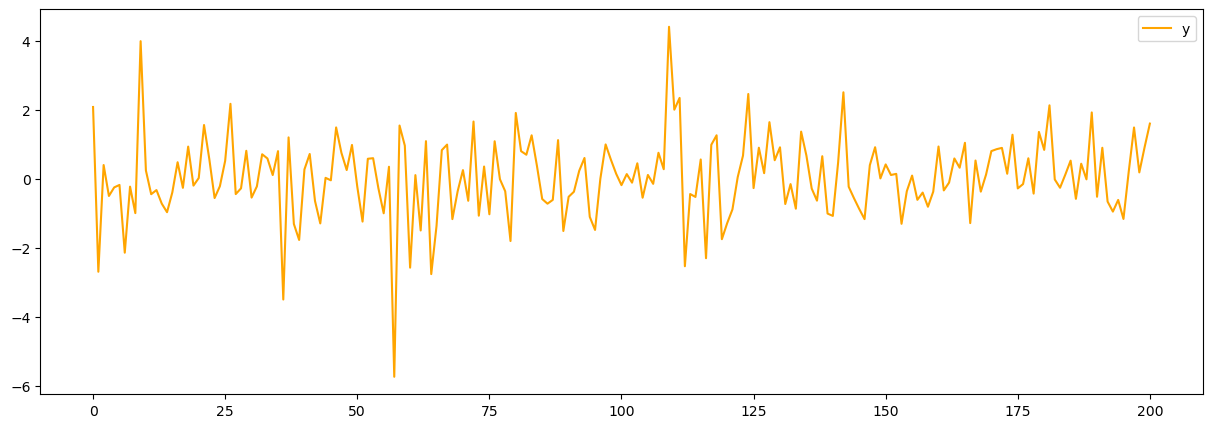

In [6]:
timesteps = np.arange(0,len(observations))
plt.figure(figsize=(15,5))
# plt.plot(timesteps,hidden_state,color="blue",label="x")
plt.plot(timesteps,observations,color="orange",label="y")
plt.legend()

In [232]:
rho_chain, sigma2_chain, beta2_chain, all_X = particle_mcmc(observations,1000,0.1,0.1,10e-4)

0.30848179384938723	0.17157111913595433	0.0003866266916606336
0.32738713202874054	0.16369981255463734	0.00038590898944373237
0.5314790441672588	0.13594222731334796	0.0003852399256545116
0.5314790441672588	0.13594222731334796	0.0003852399256545116
0.451285901641914	0.13860831038586585	0.00038557374763324644
0.5565974770905898	0.13663892793239418	0.00038548552284994257
0.5565974770905898	0.13663892793239418	0.00038548552284994257
0.5565974770905898	0.13663892793239418	0.00038548552284994257
0.47631378349230213	0.13354758241003653	0.0003857682047966082
0.47631378349230213	0.13354758241003653	0.0003857682047966082
0.4797330602176206	0.13335696824771107	0.0003853204542376061
0.4797330602176206	0.13335696824771107	0.0003853204542376061
0.662408716213363	0.13661037861480538	0.00038567201086375216
0.7319606932171798	0.13554572662495562	0.0003852375023259752
0.7319606932171798	0.13554572662495562	0.0003852375023259752
0.6724883234331422	0.13622987830324296	0.0003850541419575039
0.78261456878372

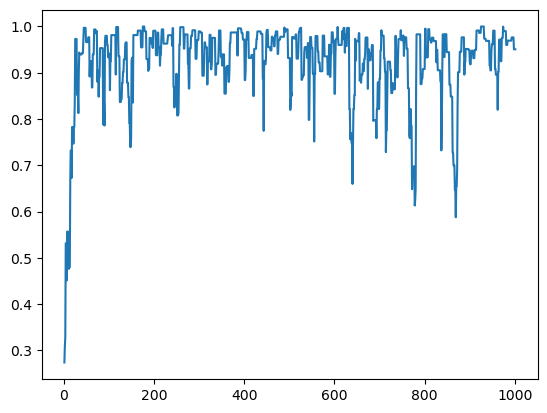

In [233]:
timesteps = np.arange(1,1002)
plt.plot(timesteps,rho_chain)

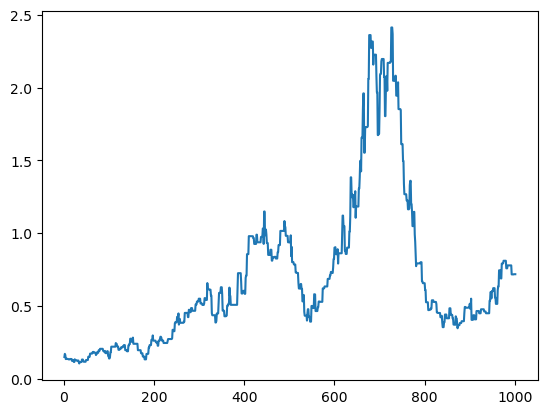

In [234]:
plt.plot(timesteps,sigma2_chain)

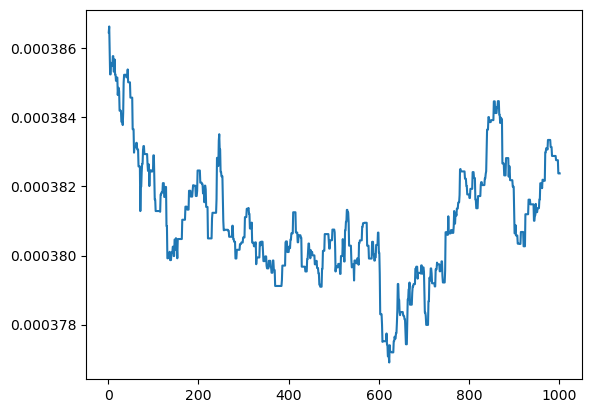

In [235]:
plt.plot(timesteps,beta2_chain)

In [236]:
rho_chain, sigma2_chain, beta2_chain, all_X = particle_mcmc2(observations,1000,0.1,0.1,10e-4)

0.2739233746429086	0.7632867726103049	0.00020064599782832789
0.20874425938173963	0.5282565631744306	5.75443941199886e-05
0.20874425938173963	0.5282565631744306	5.75443941199886e-05
0.034917619532051414	0.565638738747053	9.644879519590948e-05
0.034917619532051414	0.565638738747053	9.644879519590948e-05
0.034917619532051414	0.565638738747053	9.644879519590948e-05
0.21759327552779373	0.5897421565553232	0.0010084075144413793
0.07450597324188502	0.5641389370926821	0.0002521077605899169
0.07450597324188502	0.5641389370926821	0.0002521077605899169
0.07450597324188502	0.5641389370926821	0.0002521077605899169
0.11038331404227644	0.4514127153106717	0.0007928292600691106
-0.02937852842812788	0.4635381275670786	2.1187629286490198e-05
-0.02937852842812788	0.4635381275670786	2.1187629286490198e-05
0.09606629687672469	0.5734044245523645	0.0008190298829157614
0.09606629687672469	0.5734044245523645	0.0008190298829157614
0.09606629687672469	0.5734044245523645	0.0008190298829157614
0.056536168018067684	0

In [66]:
rho_chain, sigma2_chain, beta2_chain, all_X = particle_mcmc(observations,100,0.1,0.1,1)

-44731.71077868135
0.30848179384938723	0.17157111913595433	0.0005993966334782616
-274546.0684952801
0.30848179384938723	0.17157111913595433	0.0005993966334782616
-157926.84781977464
0.5125737059879055	0.14247884413551629	0.00010570838570288056
-277353.592884906
0.5125737059879055	0.14247884413551629	0.00010570838570288056
-86641.14642690163
0.43238056346256076	0.14527312257312078	0.0002513481604951384
-76302.81049755377
0.5376921389112366	0.14320904475729512	0.00019993625677802907
-214723.51277045195
0.5376921389112366	0.14320904475729512	0.00019993625677802907
-123083.63604367057
0.36386549906154836	0.14866383109492085	0.00020786794550745362
-72404.92063539391
0.28358180546326067	0.14530043183860347	0.0004326583120225404
-114840.89762795027
0.28358180546326067	0.14530043183860347	0.0004326583120225404
-226658.10279137164
0.28358180546326067	0.14530043183860347	0.0004326583120225404
-32613.16273939376
0.28289912747670837	0.14586681549274505	0.000994562066201943
-9330.068791251986
0.465

In [219]:
unnormalised_weights, X = SIR(observations,N=5000,rho=0.9,sigma2=0.15,beta2 = 1e-5)

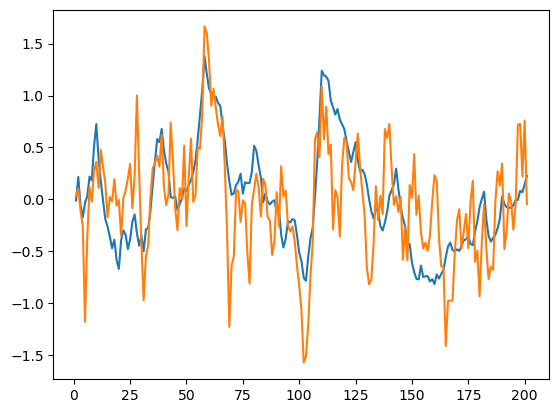

In [220]:
timesteps = np.arange(1,202)
plt.plot(timesteps,np.mean(X,axis=0))
plt.plot(timesteps,hidden_state)

Problem:
- rho is converging
- but $\sigma^2$ is not converging 
- This may indicate that $\sigma^2$ is not informing the likelihood (does not have any particular effect on the likelihood, so the random walk can move wherever it wants)

In [305]:
unnormalised_weights, X = SIR(observations,N=500,rho=0.9,sigma2=0.15,beta2=1e-5)

In [306]:
log_marginal_likelihood = compute_marginal_likelihood(unnormalised_weights)

500
[ 2.68030571  1.50022829  4.67107525  4.6567764   4.83890477  4.9347513
  2.30651297  4.72600061  4.25300746  0.26383855  4.36674623  4.42475377
  4.57803174  4.45638065  4.24445069  4.7098557   4.73114672  4.94333972
  4.23843871  4.9962872   5.12237823  2.95792729  4.68756536  4.71105157
  4.99048914  4.80603511  2.04494821  4.66834497  4.81931737  4.44513334
  4.69592663  4.9407544   4.5664749   4.70448502  5.06976095  4.44890855
 -0.32297195  4.06969106  3.96721617  3.53898054  4.55384839  4.43535079
  4.53006532  3.88895438  4.76236602  4.87171386  3.49962848  4.49286694
  4.83105996  4.22721216  4.89943881  3.80669     4.67003991  4.67996844
  4.95287435  4.15142287  4.90386893 -3.88321564  3.83812808  4.12833365
  2.96110785  4.38286601  3.82410069  4.12680295  2.5199819   3.92929739
  4.24340255  4.20496713  4.06662174  4.6001645   4.73082788  4.58954247
  3.23178724  4.18495848  4.72215765  4.19859367  4.14414247  4.84204493
  4.82291324  2.93056164  3.215809    4.36170065

In [311]:
unnormalised_weights, X = SIR(observations,N=2000,rho=0.9,sigma2=0.35,beta2=1e-5)

In [312]:
log_marginal_likelihood = compute_marginal_likelihood(unnormalised_weights)

2000
[ 2.67997865  1.77742235  4.56650033  4.60632242  4.85144195  5.05074423
  2.10515331  4.63239452  4.16625204  0.75404142  4.2352572   4.36951225
  4.58492691  4.41326708  4.1636122   4.73391079  4.74660841  5.04133675
  4.05015826  5.05174897  5.30222362  2.73113643  4.64358122  4.67134454
  5.00561601  4.77267853  2.028687    4.55178193  4.76217793  4.35518855
  4.6703275   5.00695554  4.47567432  4.68254921  5.20026703  4.28124368
  0.1108904   4.01047918  3.91224584  3.5024516   4.49650273  4.40271631
  4.51562099  3.7453547   4.81216845  5.03143069  3.22114353  4.44193506
  4.85513808  4.12679319  4.90765525  3.70513911  4.62204987  4.62410832
  4.9601818   4.00988683  4.8773446  -1.92476635  3.71515163  4.0005371
  2.98058736  4.27144095  3.73291795  4.06770629  2.50961639  3.86400795
  4.20058518  4.1452906   3.99381918  4.62568983  4.83608948  4.58396822
  3.07381856  4.11337291  4.70662926  4.09322007  4.05473872  4.85203903
  4.87802394  2.71659465  3.23654657  4.3064235

In [319]:
sigma2s = np.arange(0,4,0.05)
likelihoods = []
for sigma2 in sigma2s:
    unnormalised_weights, X = SIR(observations,N=5000,rho=0.9,sigma2=sigma2,beta2=1e-5)
    likelihoods.append(compute_marginal_likelihood(unnormalised_weights))

5000
[  2.68374084   1.27506795   4.74554074   4.70286862   4.79605409
   4.81351473   2.57143666   4.80271385   4.34133201  -2.94999733
   4.79898897   4.72941358   4.77605054   4.57411041   4.36733229
   4.75439995   4.71905776   4.7981714    4.4045941    4.8137797
   4.83357509   3.63377772   4.67399118   4.67934829   4.81172808
   4.70171805   2.49342428   4.73729618   4.79744347   4.51021778
   4.68765743   4.81185327   4.58677134   4.6651959    4.83111356
   4.51888926  -1.26888911   4.12227669   3.98112625   3.26683424
   4.80093536   4.58058301   4.63033658   4.00026036   4.83693184
   4.83624805   3.73595152   4.55609748   4.80578681   4.3600259
   4.81146616   4.06785498   4.67069687   4.66100723   4.79916238
   4.33761644   4.77737928 -11.59392549   3.65290983   4.37860788
   1.52414881   4.83202032   3.71567436   4.24621681   1.02710368
   3.90564348   4.49486449   4.34960277   4.15434649   4.77206676
   4.80636871   4.63391274   3.46714817   4.26553663   4.77521812
   4.30

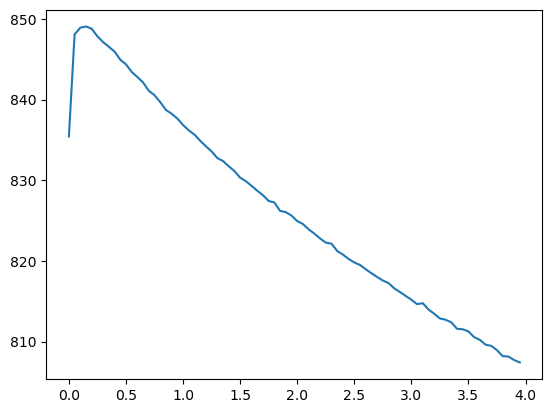

In [320]:
plt.plot(sigma2s,likelihoods)

#### TESTING BETA AND SIGMA INDIVIDUALLY AND THEN TOGETHER:

In [21]:
hidden_state,observations = generate_data(1000,rho=0.9,sigma=np.sqrt(0.15),beta=np.sqrt(1))

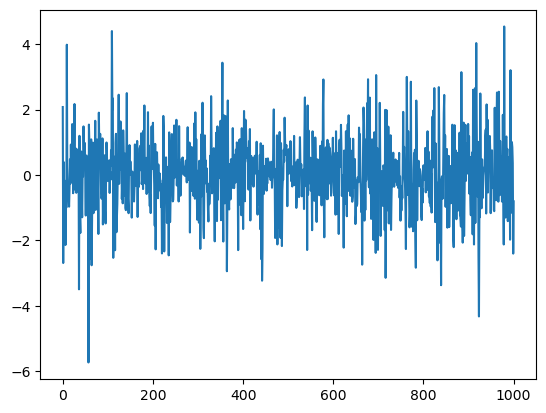

In [83]:
timesteps = np.arange(1001)
plt.plot(timesteps,observations)

In [80]:
sigma2s = np.arange(0,4,0.05)
likelihoods = []
for sigma2 in sigma2s:
    unnormalised_weights, X = SIR(observations,N=1000,rho=0.9,sigma2=sigma2,beta2=1)
    likelihoods.append(compute_marginal_likelihood(unnormalised_weights))

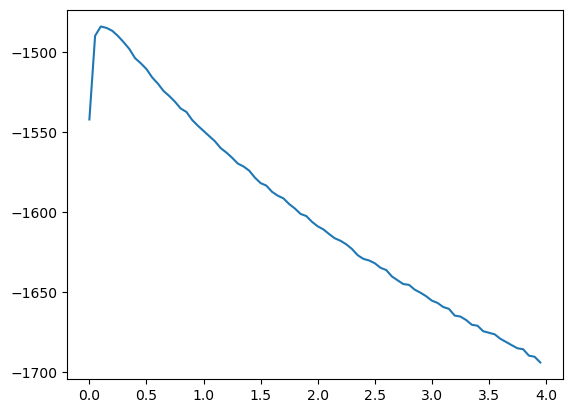

In [81]:
plt.plot(sigma2s,likelihoods)

In [86]:
def particle_mcmc_for_sigma(y,iters,sd_sigma2):

    # FIRST ITERATION
    # List to store MCMC Chain
    sigma2_chain = []

    rho = 0.9
    beta2 = 1

    # Set standard deviation of random walk for rho, sigma^2 and beta^2
    sd_sigma2 = sd_sigma2
    
    # Sample starting values randomly from the prior
    rng = np.random.default_rng(seed=0)
    # sigma2 = stats.invgamma.rvs(a=1,random_state=rng)
    sigma2 = 0.5
    
    # Append to mcmc chains
    sigma2_chain.append(sigma2)

    # Run SIR filter to get _unnormalised_ weights at each timestep
    unnormalised_weights, X = SIR(y,rho,sigma2,beta2,N=500)

    # Estimate normalising constant and store as previous marginal likelihood
    log_marginal_likelihood_prev = compute_marginal_likelihood(unnormalised_weights)

    # NEXT ITERATIONS
    for i in range(1,iters+1):

        rng1 = np.random.default_rng(i)
        rng2 = np.random.default_rng(2000*i)
        rng3 = np.random.default_rng(3000*i)

        # Sample new rho, sigma2 and beta2 from the mcmc proposal
        # For the proposal on sigma2 and beta2, use a log scale to prevent proposing negative values
        
        log_new_sigma2 = np.log(sigma2) + sd_sigma2*stats.norm.rvs(random_state=rng2)
        new_sigma2 = np.exp(log_new_sigma2)

        # Run SIR filter and estimate normalising constant/marginal likelihood as in first iteration
        unnormalised_weights, X = SIR(y,rho,new_sigma2,beta2,N=500)
        
        log_marginal_likelihood = compute_marginal_likelihood(unnormalised_weights)

        print(log_marginal_likelihood)

        # Compute Metropolis-Hastings acceptance ratio
        # Need to correct log density with Jacobian to account for doing random walk in log space
        
        log_ratio = log_marginal_likelihood + log_prior(rho,new_sigma2,beta2) + np.log(new_sigma2)
        log_ratio = log_ratio - log_marginal_likelihood_prev - log_prior(rho,sigma2,beta2) - np.log(sigma2)

        # Accept move with probability given by ratio, else reject
        if log_ratio > np.log(stats.uniform.rvs(random_state=rng1)):
            sigma2 = new_sigma2

        # Add values to the mcmc chains 
        sigma2_chain.append(sigma2)

        print(rho,sigma2,beta2,sep="\t")

        # Update the previous value of log marginal likelihood
        log_marginal_likelihood_prev = log_marginal_likelihood

    return sigma2_chain

In [87]:
sigma2_chain = particle_mcmc_for_sigma(observations,iters=100,sd_sigma2=0.2)

-1526.2440750436822
0.9	0.5	1
-1509.8087683261604
0.9	0.4551745801947038	1
-1496.4797532165437
0.9	0.31389933711809526	1
-1488.7830444215444
0.9	0.19617594462393584	1
-1488.8298779536515
0.9	0.20394615837687444	1
-1489.1235471549296
0.9	0.19819189117875885	1
-1487.5827186957295
0.9	0.17351139385977876	1
-1488.5195346986227
0.9	0.186981114361922	1
-1488.2020383341394
0.9	0.17861622765452112	1
-1488.0865093453333
0.9	0.17861622765452112	1
-1486.5220383443607
0.9	0.1781067091099653	1
-1487.0537292449462
0.9	0.17949794156661517	1
-1487.2664037910176
0.9	0.1883629291165195	1
-1490.0532990955353
0.9	0.1883629291165195	1
-1488.5219850989283
0.9	0.17896032566749978	1
-1487.5716184768874
0.9	0.18077144876428508	1
-1485.8615014811683
0.9	0.14775477930232306	1
-1488.98307664798
0.9	0.14775477930232306	1
-1486.0582629882697
0.9	0.1313209159159417	1
-1485.3104232993205
0.9	0.14540753639710896	1
-1486.8131046095311
0.9	0.14540753639710896	1
-1487.153515109072
0.9	0.14897689405086254	1
-1491.33084026

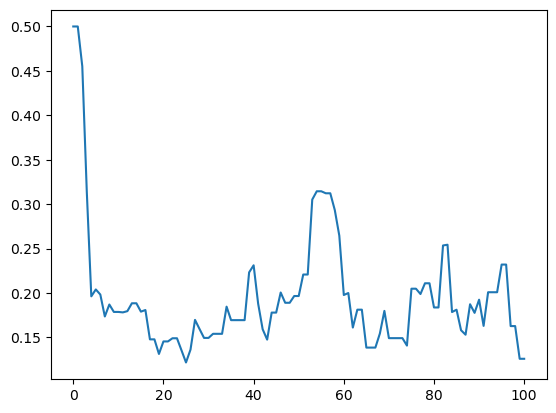

In [88]:
timesteps = np.arange(101)
plt.plot(timesteps,sigma2_chain)

In [90]:
beta2s = np.arange(0.05,4,0.05)
likelihoods = []
for beta2 in beta2s:
    unnormalised_weights, X = SIR(observations,N=1000,rho=0.9,sigma2=0.15,beta2=beta2)
    likelihoods.append(compute_marginal_likelihood(unnormalised_weights))

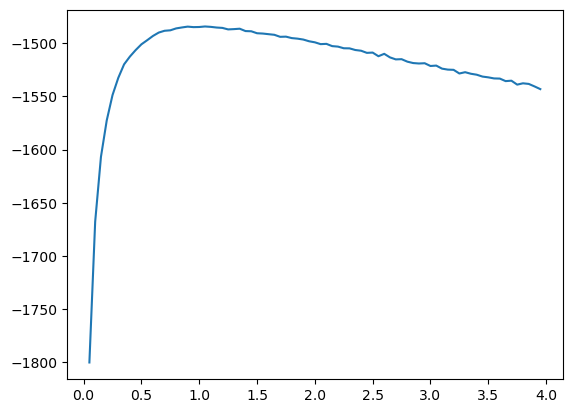

In [91]:
plt.plot(beta2s,likelihoods)

In [99]:
def particle_mcmc_for_beta(y,iters,sd_beta2):

    # FIRST ITERATION
    # List to store MCMC Chain
    beta2_chain = []

    rho = 0.9
    sigma2 = 0.15

    # Set standard deviation of random walk for rho, sigma^2 and beta^2
    sd_beta2 = sd_beta2
    
    # Sample starting values randomly from the prior
    rng = np.random.default_rng(seed=0)
    # sigma2 = stats.invgamma.rvs(a=1,random_state=rng)
    beta2 = 4
    
    # Append to mcmc chains
    beta2_chain.append(beta2)

    # Run SIR filter to get _unnormalised_ weights at each timestep
    unnormalised_weights, X = SIR(y,rho,sigma2,beta2,N=500)

    # Estimate normalising constant and store as previous marginal likelihood
    log_marginal_likelihood_prev = compute_marginal_likelihood(unnormalised_weights)

    # NEXT ITERATIONS
    for i in range(1,iters+1):

        rng1 = np.random.default_rng(i)
        rng2 = np.random.default_rng(2000*i)
        rng3 = np.random.default_rng(3000*i)

        # Sample new rho, sigma2 and beta2 from the mcmc proposal
        # For the proposal on sigma2 and beta2, use a log scale to prevent proposing negative values
        
        log_new_beta2 = np.log(beta2) + sd_beta2*stats.norm.rvs(random_state=rng2)
        new_beta2 = np.exp(log_new_beta2)

        # Run SIR filter and estimate normalising constant/marginal likelihood as in first iteration
        unnormalised_weights, X = SIR(y,rho,sigma2,new_beta2,N=500)
        
        log_marginal_likelihood = compute_marginal_likelihood(unnormalised_weights)

        print(log_marginal_likelihood)

        # Compute Metropolis-Hastings acceptance ratio
        # Need to correct log density with Jacobian to account for doing random walk in log space
        
        log_ratio = log_marginal_likelihood + log_prior(rho,sigma2,new_beta2) + np.log(new_beta2)
        log_ratio = log_ratio - log_marginal_likelihood_prev - log_prior(rho,sigma2,beta2) - np.log(beta2)

        # Accept move with probability given by ratio, else reject
        if log_ratio > np.log(stats.uniform.rvs(random_state=rng1)):
            beta2 = new_beta2

        # Add values to the mcmc chains 
        beta2_chain.append(beta2)

        print(rho,sigma2,beta2,sep="\t")

        # Update the previous value of log marginal likelihood
        log_marginal_likelihood_prev = log_marginal_likelihood

    return beta2_chain

In [100]:
beta2_chain = particle_mcmc_for_beta(observations,iters=100,sd_beta2=0.2)

-1568.916786572223
0.9	0.15	4
-1538.3497084267042
0.9	0.15	3.6413966415576295
-1512.8252361726206
0.9	0.15	2.511194696944761
-1493.0599025239112
0.9	0.15	1.5694075569914863
-1493.0485747997986
0.9	0.15	1.631569267014995
-1492.431715608289
0.9	0.15	1.5855351294300701
-1489.8272272652234
0.9	0.15	1.3880911508782294
-1491.6747001235897
0.9	0.15	1.3880911508782294
-1488.5775568586178
0.9	0.15	1.325992765935634
-1488.2164312446253
0.9	0.15	1.2360560705147503
-1488.095760660831
0.9	0.15	1.232530111545019
-1489.5481816835324
0.9	0.15	1.232530111545019
-1489.2338554964438
0.9	0.15	1.2934019187555423
-1487.0404510861222
0.9	0.15	1.2733206169962386
-1489.455768307531
0.9	0.15	1.2733206169962386
-1488.1307376370817
0.9	0.15	1.2862069389810313
-1486.9389042683633
0.9	0.15	1.0512900333838864
-1487.7753707632262
0.9	0.15	1.241709246037384
-1486.508392815907
0.9	0.15	1.1036014960793825
-1488.4559285233618
0.9	0.15	1.1036014960793825
-1485.3362790106958
0.9	0.15	0.8808450708129388
-1488.446032238713
0

In [105]:
def particle_mcmc_for_beta_and_sigma(y,iters,sd_sigma2,sd_beta2):

    # FIRST ITERATION
    # List to store MCMC Chain
    sigma2_chain = []
    beta2_chain = []

    rho = 0.9

    # Set standard deviation of random walk for rho, sigma^2 and beta^2
    sd_beta2 = sd_beta2
    sd_sigma2 = sd_sigma2
    
    # Sample starting values randomly from the prior
    rng = np.random.default_rng(seed=0)
    # sigma2 = stats.invgamma.rvs(a=1,random_state=rng)
    beta2 = 5
    sigma2 = 1
    
    # Append to mcmc chains
    beta2_chain.append(beta2)
    sigma2_chain.append(sigma2)

    # Run SIR filter to get _unnormalised_ weights at each timestep
    unnormalised_weights, X = SIR(y,rho,sigma2,beta2,N=500)

    # Estimate normalising constant and store as previous marginal likelihood
    log_marginal_likelihood_prev = compute_marginal_likelihood(unnormalised_weights)

    # NEXT ITERATIONS
    for i in range(1,iters+1):

        rng1 = np.random.default_rng(i)
        rng2 = np.random.default_rng(2000*i)
        rng3 = np.random.default_rng(3000*i)

        # Sample new rho, sigma2 and beta2 from the mcmc proposal
        # For the proposal on sigma2 and beta2, use a log scale to prevent proposing negative values
        
        log_new_beta2 = np.log(beta2) + sd_beta2*stats.norm.rvs(random_state=rng2)
        log_new_sigma2 = np.log(sigma2) + sd_sigma2*stats.norm.rvs(random_state=rng3)
        new_beta2 = np.exp(log_new_beta2)
        new_sigma2 = np.exp(log_new_sigma2)

        # Run SIR filter and estimate normalising constant/marginal likelihood as in first iteration
        unnormalised_weights, X = SIR(y,rho,new_sigma2,new_beta2,N=500)
        
        log_marginal_likelihood = compute_marginal_likelihood(unnormalised_weights)

        print(log_marginal_likelihood)

        # Compute Metropolis-Hastings acceptance ratio
        # Need to correct log density with Jacobian to account for doing random walk in log space
        
        log_ratio = log_marginal_likelihood + log_prior(rho,sigma2,new_beta2) + np.log(new_beta2) + np.log(new_sigma2)
        log_ratio = log_ratio - log_marginal_likelihood_prev - log_prior(rho,sigma2,beta2) - np.log(beta2) - np.log(new_beta2)

        # Accept move with probability given by ratio, else reject
        if log_ratio > np.log(stats.uniform.rvs(random_state=rng1)):
            beta2 = new_beta2
            sigma2 = new_sigma2

        # Add values to the mcmc chains 
        beta2_chain.append(beta2)
        sigma2_chain.append(sigma2)

        print(rho,sigma2,beta2,sep="\t")

        # Update the previous value of log marginal likelihood
        log_marginal_likelihood_prev = log_marginal_likelihood

    return sigma2_chain, beta2_chain

In [106]:
beta2_chain = particle_mcmc_for_beta_and_sigma(observations,iters=1000,sd_sigma2=0.2,sd_beta2=0.2)

-1573.4383852044311
0.9	1	5
-1546.6774211975785
0.9	0.6896240492687944	4.551745801947037
-1527.102854130476
0.9	0.48740662334171964	3.1389933711809515
-1516.4379652074092
0.9	0.4736546215037798	1.961759446239358
-1523.6745036041873
0.9	0.4736546215037798	1.961759446239358
-1513.6294333277144
0.9	0.4524649561151836	1.9064091120044349
-1506.6472895866673
0.9	0.37093355207927386	1.6690072450669677
-1507.570639208157
0.9	0.37093355207927386	1.6690072450669677
-1508.896234898601
0.9	0.37093355207927386	1.6690072450669677
-1504.2019155523335
0.9	0.3524174825294092	1.5558052728458591
-1497.8277221287917
0.9	0.27937282383754813	1.5513672010724147
-1501.4062375499773
0.9	0.27937282383754813	1.5513672010724147
-1503.3556904375196
0.9	0.27937282383754813	1.5513672010724147
-1494.697072227019
0.9	0.22298282094635255	1.5272807415949181
-1492.4949142037985
0.9	0.19168143121862252	1.4510427300291788
-1492.7865713556307
0.9	0.19168143121862252	1.4510427300291788
-1488.9999512618956
0.9	0.2013940645446

In [107]:
sigma2_chain = beta2_chain[0]
beta2_chain = beta2_chain[1]

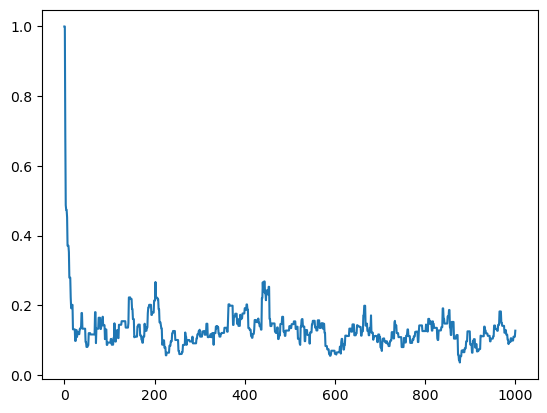

In [109]:
timesteps = np.arange(1001)
plt.plot(timesteps,sigma2_chain)

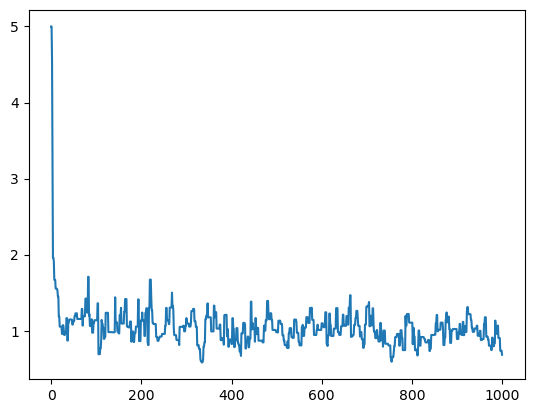

In [110]:
timesteps = np.arange(1001)
plt.plot(timesteps,beta2_chain)

In [62]:
def particle_mcmc(y,iters,sd_rho,sd_sigma2,sd_beta2):

    # FIRST ITERATION
    # List to store MCMC Chain
    rho_chain = []
    sigma2_chain = []
    beta2_chain = []
    V_chain = []

    all_X = []
    marginal_likelihoods = []

    # Set standard deviation of random walk for rho, sigma^2 and beta^2
    sd_rho = sd_rho
    sd_sigma2 = sd_sigma2
    sd_beta2 = sd_beta2
    
    # Sample starting values randomly from the prior
    rng = np.random.default_rng(seed=0)
    rho = stats.uniform.rvs(loc=-1,scale=2,random_state=rng)
    # sigma2 = stats.invgamma.rvs(a=1,random_state=rng)
    sigma2 = 0.6
    beta2 = 4

    # Append to mcmc chains
    rho_chain.append(rho)
    sigma2_chain.append(sigma2)
    beta2_chain.append(beta2)

    # Run SIR filter to get _unnormalised_ weights at each timestep
    unnormalised_weights, X = SIR(y,rho,sigma2,beta2,N=1000)
    all_X.append(X)

    # Estimate normalising constant and store as previous marginal likelihood
    log_marginal_likelihood_prev = compute_marginal_likelihood(unnormalised_weights)

    # NEXT ITERATIONS
    for i in range(1,iters+1):

        rng1 = np.random.default_rng(i)
        rng2 = np.random.default_rng(2000*i)
        rng3 = np.random.default_rng(3000*i)

        # Sample new rho, sigma2 and beta2 from the mcmc proposal
        # For the proposal on sigma2 and beta2, use a log scale to prevent proposing negative values

        mean = np.array([rho,np.log(sigma2)])
        cov = np.array([[0.01,-0.008],[-0.008,0.01]])
        new_rho, log_new_sigma2 = stats.multivariate_normal.rvs(mean,cov,random_state=rng1)
        
        # new_rho = rho + sd_rho*stats.norm.rvs(random_state=rng1)
        # log_new_sigma2 = np.log(sigma2) + sd_sigma2*stats.norm.rvs(random_state=rng2)
        log_new_beta2 = np.log(beta2) + sd_beta2*stats.norm.rvs(random_state=rng3)

        new_sigma2 = np.exp(log_new_sigma2)
        new_beta2 = np.exp(log_new_beta2)

        if new_rho > 1 or new_rho <-1:
            rho_chain.append(rho)
            sigma2_chain.append(sigma2)
            beta2_chain.append(beta2)

            continue

        # Run SIR filter and estimate normalising constant/marginal likelihood as in first iteration
        unnormalised_weights, X = SIR(y,new_rho,new_sigma2,new_beta2,N=1000)
        all_X.append(X)
        
        log_marginal_likelihood = compute_marginal_likelihood(unnormalised_weights)

        # Compute Metropolis-Hastings acceptance ratio
        # Need to correct log density with Jacobian to account for doing random walk in log space
        
        log_ratio = log_marginal_likelihood + log_prior(new_rho,new_sigma2,new_beta2) + np.log(new_sigma2) + np.log(new_beta2)
        log_ratio = log_ratio - log_marginal_likelihood_prev - log_prior(rho,sigma2,beta2) - np.log(sigma2) - np.log(beta2)

        # Accept move with probability given by ratio, else reject
        rng4 = np.random.default_rng(seed=4000*i)
        if log_ratio > np.log(stats.uniform.rvs(random_state=rng4)):
            rho = new_rho
            sigma2 = new_sigma2
            beta2 = new_beta2

        V = sigma2/(1-rho**2)

        # Add values to the mcmc chains 
        rho_chain.append(rho)
        sigma2_chain.append(sigma2)
        beta2_chain.append(beta2)
        V_chain.append(V)

        print(rho,sigma2,beta2,sep="\t")
        print(V)
        print("\n")

        # Update the previous value of log marginal likelihood
        log_marginal_likelihood_prev = log_marginal_likelihood

    return rho_chain, sigma2_chain, beta2_chain, all_X, V_chain

In [70]:
rho_chain, sigma2_chain, beta2_chain, all_X, V_chain = particle_mcmc(observations,3000,0.2,0.2,0.2)

0.2739233746429086	0.6	4
0.6486725023883015


0.23945743888433538	0.6008432448314933	2.758496197075177
0.6373911684035579


-0.034978373782653255	0.6725896697907544	1.9496264933668779
0.6734135823068366


0.021330918343657933	0.6287766188320815	1.8946184860151185
0.6290628475088801


0.021330918343657933	0.6287766188320815	1.8946184860151185
0.6290628475088801


-0.022398826740448574	0.7349930011976464	1.8098598244607336
0.7353619377524306


-0.013068365941496733	0.7420560971778702	1.4837342083170946
0.7421828487889651


0.10956970759512666	0.6032007478808978	1.4953239973709025
0.6105304843231998


0.10956970759512666	0.6032007478808978	1.4953239973709025
0.6105304843231998


0.1913142912385033	0.5309409917647536	1.4206811860649462
0.5511123416758678


0.23106947321969182	0.5560697254477306	1.1262202768011658
0.5874346851917895


0.23106947321969182	0.5560697254477306	1.1262202768011658
0.5874346851917895


0.23106947321969182	0.5560697254477306	1.1262202768011658
0.5874346851917895




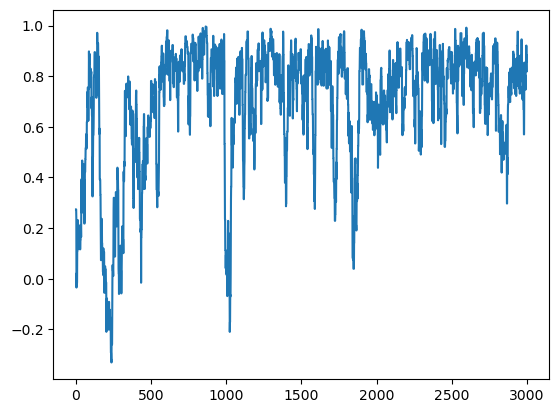

In [72]:
timesteps = np.arange(3001)
plt.plot(timesteps,rho_chain)

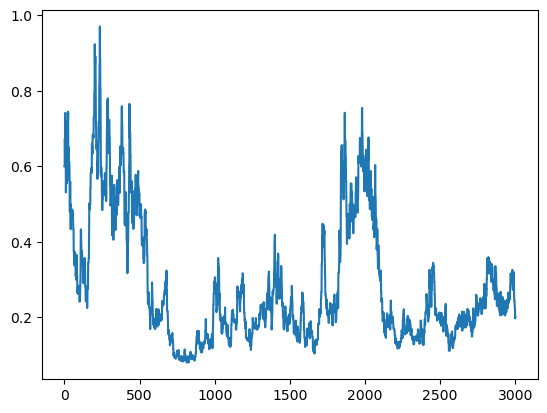

In [73]:
plt.plot(timesteps,sigma2_chain)

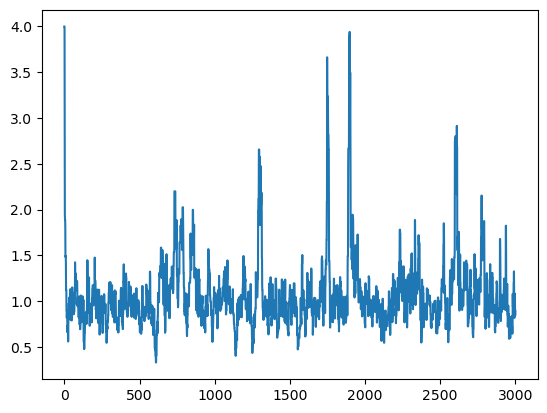

In [74]:
plt.plot(timesteps,beta2_chain)

(array([  3.,   2.,   2.,   0.,  10.,   5.,  10.,   3.,   3.,  10.,  11.,
          8.,   4.,  31.,   9.,  23.,  20.,  17.,  15.,  13.,  24.,  24.,
         12.,  14.,  31.,  25.,  20.,  37.,  26.,  33.,  40.,  41.,  55.,
         59.,  78.,  86., 110.,  91.,  79., 124., 148., 191., 235., 221.,
        231., 240., 213., 167.,  91.,  56.]),
 array([-0.33110159, -0.30454442, -0.27798726, -0.2514301 , -0.22487294,
        -0.19831577, -0.17175861, -0.14520145, -0.11864429, -0.09208713,
        -0.06552996, -0.0389728 , -0.01241564,  0.01414152,  0.04069869,
         0.06725585,  0.09381301,  0.12037017,  0.14692733,  0.1734845 ,
         0.20004166,  0.22659882,  0.25315598,  0.27971315,  0.30627031,
         0.33282747,  0.35938463,  0.38594179,  0.41249896,  0.43905612,
         0.46561328,  0.49217044,  0.51872761,  0.54528477,  0.57184193,
         0.59839909,  0.62495625,  0.65151342,  0.67807058,  0.70462774,
         0.7311849 ,  0.75774207,  0.78429923,  0.81085639,  0.83741355,
 

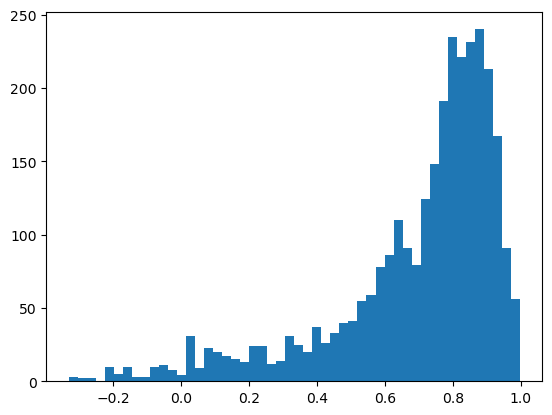

In [78]:
plt.hist(rho_chain,bins=50)

(array([111.,  69., 136., 242., 207., 260., 284., 220., 171., 134., 121.,
         95.,  63.,  65.,  55.,  42.,  17.,  19.,  30.,  41.,  32.,  57.,
         56.,  47.,  44.,  58.,  52.,  29.,  37.,  38.,  30.,  22.,  29.,
         25.,  10.,  11.,   9.,   6.,   4.,   4.,   5.,   3.,   0.,   0.,
          4.,   5.,   0.,   1.,   0.,   1.]),
 array([0.07971277, 0.09753359, 0.1153544 , 0.13317522, 0.15099604,
        0.16881686, 0.18663767, 0.20445849, 0.22227931, 0.24010013,
        0.25792095, 0.27574176, 0.29356258, 0.3113834 , 0.32920422,
        0.34702503, 0.36484585, 0.38266667, 0.40048749, 0.41830831,
        0.43612912, 0.45394994, 0.47177076, 0.48959158, 0.50741239,
        0.52523321, 0.54305403, 0.56087485, 0.57869566, 0.59651648,
        0.6143373 , 0.63215812, 0.64997894, 0.66779975, 0.68562057,
        0.70344139, 0.72126221, 0.73908302, 0.75690384, 0.77472466,
        0.79254548, 0.81036629, 0.82818711, 0.84600793, 0.86382875,
        0.88164957, 0.89947038, 0.9172912 , 0.

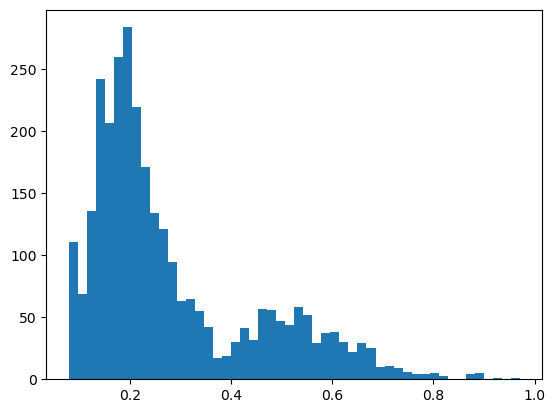

In [80]:
plt.hist(sigma2_chain,bins=50)

(array([  7.,  10.,  28.,  39., 112., 232., 263., 395., 469., 399., 254.,
        178., 175.,  92.,  60.,  55.,  44.,  28.,  23.,  15.,  14.,  17.,
          8.,   8.,   6.,  11.,   0.,   0.,   2.,   8.,   2.,  12.,   7.,
          9.,   0.,   2.,   1.,   1.,   0.,   5.,   0.,   1.,   0.,   2.,
          0.,   1.,   0.,   0.,   3.,   3.]),
 array([0.33092931, 0.40431072, 0.47769214, 0.55107355, 0.62445497,
        0.69783638, 0.77121779, 0.84459921, 0.91798062, 0.99136203,
        1.06474345, 1.13812486, 1.21150628, 1.28488769, 1.3582691 ,
        1.43165052, 1.50503193, 1.57841334, 1.65179476, 1.72517617,
        1.79855759, 1.871939  , 1.94532041, 2.01870183, 2.09208324,
        2.16546466, 2.23884607, 2.31222748, 2.3856089 , 2.45899031,
        2.53237172, 2.60575314, 2.67913455, 2.75251597, 2.82589738,
        2.89927879, 2.97266021, 3.04604162, 3.11942303, 3.19280445,
        3.26618586, 3.33956728, 3.41294869, 3.4863301 , 3.55971152,
        3.63309293, 3.70647434, 3.77985576, 3.

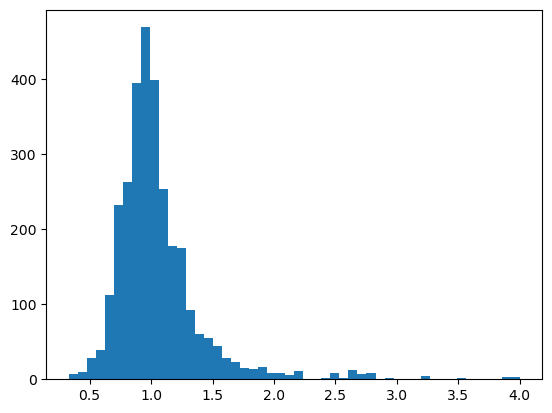

In [82]:
plt.hist(beta2_chain,bins=50)

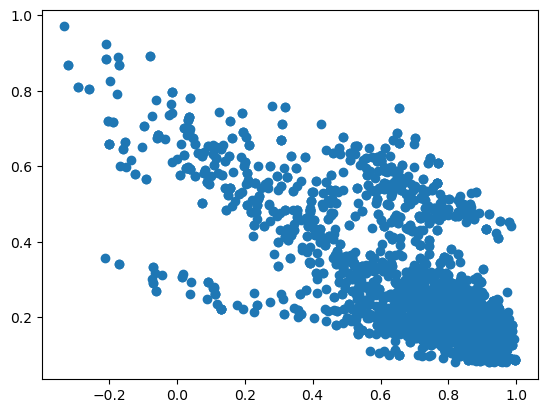

In [76]:
plt.scatter(rho_chain,sigma2_chain)

To note:
- Appears to converge with only $\beta^2$ and $\sigma^2$
- $\sigma^2$ stops converging once you add in $\rho$
- This is because $\rho$ and $\sigma^2$ are correlated, so sample them from a bivariate proposal with some correlation

To try:
- Fix a good N by running SIR filter many times
- Propose $\rho$ and $\sigma^2$ independently using the log scale for $\rho$ instead of regular
- Use a beta prior for $\rho$
- If that doesn't work, propose $\rho$ and $\sigma^2$ together from bivariate normal with some correlation

In [140]:
def particle_mcmc_v2(y,iters,sd_rho,sd_sigma2,sd_beta2):

    rng = np.random.default_rng(1000)

    # FIRST ITERATION
    # List to store MCMC Chain
    rho_chain = []
    sigma2_chain = []
    beta2_chain = []
    acceptance_rate = []
    acceptances = 1

    # Set standard deviation of random walk for rho, sigma^2 and beta^2
    sd_rho = sd_rho
    sd_sigma2 = sd_sigma2
    sd_beta2 = sd_beta2
    
    rho = 0.5
    sigma2 = 0.6
    beta2 = 4

    # Append to mcmc chains
    rho_chain.append(rho)
    sigma2_chain.append(sigma2)
    beta2_chain.append(beta2)

    # Run SIR filter to get _unnormalised_ weights at each timestep
    unnormalised_weights, X = SIR(y,rho,sigma2,beta2,N=1000,rng=rng)

    # Estimate normalising constant and store as previous marginal likelihood
    log_marginal_likelihood_prev = compute_marginal_likelihood(unnormalised_weights)

    # NEXT ITERATIONS
    for i in range(1,iters+1):

        # Sample new rho, sigma2 and beta2 from the mcmc proposal
        # For the proposal on sigma2 and beta2, use a log scale to prevent proposing negative values

        x = np.log(1+rho)-np.log(1-rho)
        mean = np.array([x,np.log(sigma2)])
        cov = np.array([[sd_rho**2,-0.8*sd_rho*sd_sigma2],[-0.8*sd_rho*sd_sigma2,sd_sigma2**2]])
        new_x, log_new_sigma2 = stats.multivariate_normal.rvs(mean,cov,random_state=rng)
        
        # new_rho = rho + sd_rho*stats.norm.rvs(random_state=rng1)
        # log_new_sigma2 = np.log(sigma2) + sd_sigma2*stats.norm.rvs(random_state=rng2)
        log_new_beta2 = np.log(beta2) + sd_beta2*stats.norm.rvs(random_state=rng)

        new_rho = (np.exp(new_x)-1)/(np.exp(new_x)+1)
        new_sigma2 = np.exp(log_new_sigma2)
        new_beta2 = np.exp(log_new_beta2)

        # Run SIR filter and estimate normalising constant/marginal likelihood as in first iteration
        unnormalised_weights, X = SIR(y,new_rho,new_sigma2,new_beta2,N=1000,rng=rng)
        
        log_marginal_likelihood = compute_marginal_likelihood(unnormalised_weights)

        # Compute Metropolis-Hastings acceptance ratio
        # Need to correct log density with Jacobian to account for doing random walk in log space
        
        log_ratio = log_marginal_likelihood + log_prior(new_rho,new_sigma2,new_beta2) + np.log(new_sigma2) + np.log(new_beta2) + np.log(1-new_rho**2)
        log_ratio = log_ratio - log_marginal_likelihood_prev - log_prior(rho,sigma2,beta2) - np.log(sigma2) - np.log(beta2) - np.log(1-rho**2)

        # Accept move with probability given by ratio, else reject
        if log_ratio > np.log(stats.uniform.rvs(random_state=rng)):
            rho = new_rho
            sigma2 = new_sigma2
            beta2 = new_beta2
            acceptances += 1

        # Add values to the mcmc chains 
        rho_chain.append(rho)
        sigma2_chain.append(sigma2)
        beta2_chain.append(beta2)
        acceptance_rate.append(acceptances/(i+1))

        log_marginal_likelihood_prev = log_marginal_likelihood

        print(rho,sigma2,beta2,sep="\t")
        print(acceptance_rate[-1])
        print("\n")

    return rho_chain, sigma2_chain, beta2_chain

In [87]:
rho_chain, sigma2_chain, beta2_chain, all_X, V_chain = particle_mcmc_v2(observations,3000,0.1,0.1,0.2)

0.5	0.6	4
0.7999999999999999


0.48696424209858	0.6008432448314933	2.758496197075177
0.7876132651785241


0.3755383491619295	0.6725896697907544	1.9496264933668779
0.7830179485290476


0.3994630910684439	0.6287766188320815	1.8946184860151185
0.7481612844342233


0.3994630910684439	0.6287766188320815	1.8946184860151185
0.7481612844342233


0.3809282795194442	0.7349930011976464	1.8098598244607336
0.8597478818037506


0.38490945144885763	0.7420560971778702	1.4837342083170946
0.8711166305557634


0.43587693645630265	0.6032007478808978	1.4953239973709025
0.7446818959956929


0.43587693645630265	0.6032007478808978	1.4953239973709025
0.7446818959956929


0.468386683020411	0.5309409917647536	1.4206811860649462
0.6801582465381926


0.48375826708843	0.5560697254477306	1.1262202768011658
0.7259604971868497


0.48375826708843	0.5560697254477306	1.1262202768011658
0.7259604971868497


0.48375826708843	0.5560697254477306	1.1262202768011658
0.7259604971868497


0.44576372105856404	0.5758820111654376	0

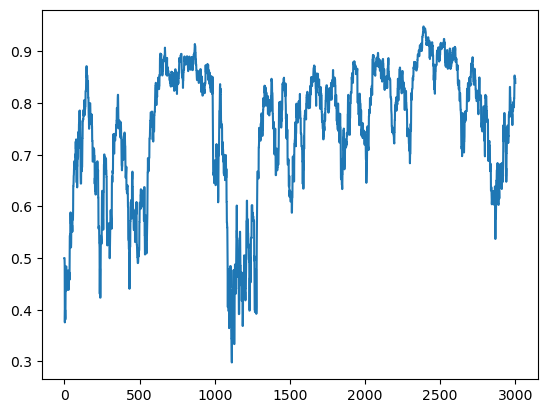

In [89]:
timesteps = np.arange(3001)
plt.plot(timesteps,rho_chain)

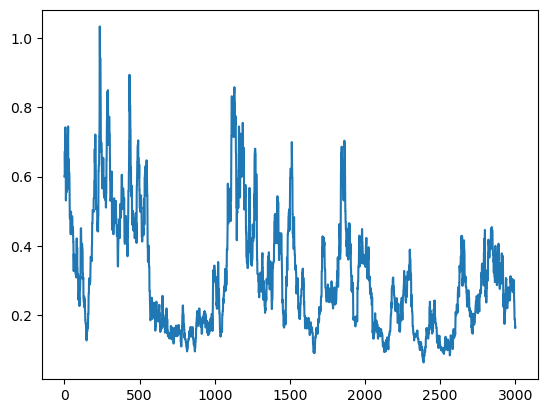

In [90]:
plt.plot(timesteps,sigma2_chain)

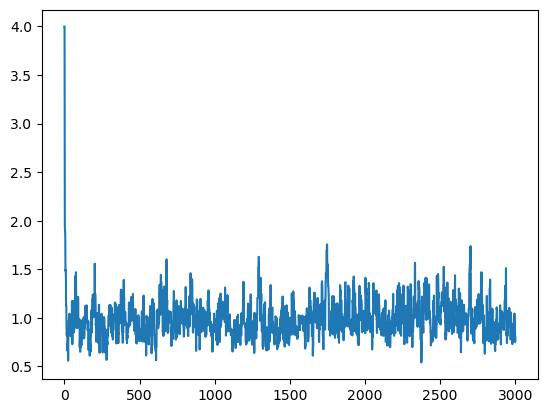

In [91]:
plt.plot(timesteps,beta2_chain)

In [119]:
def log_prior(rho,sigma2,beta2):

    # Uniform prior for rho
    if rho>-1 and rho<1:
        log_prho = np.log(1/2)
    else:
        log_prho = float("-inf")

    # IG(1,1) prior for sigma2
    # if sigma2 > 0:
    #     log_psigma2 = -2*np.log(sigma2) - 1/sigma2
    # else:
    #     log_psigma2 = float("-inf")

    # IG(2,0.1) prior for sigma2
    a = 2
    b = 0.1
    if sigma2 > 0:
        log_psigma2 = a*np.log(b) - np.log(gamma(a)) - (a+1)*np.log(sigma2) - b/sigma2
    else:
        log_psigma2 = float("-inf")
    

    # IG(1,1) prior for beta2
    if beta2 > 0:
        log_pbeta2 = -2*np.log(beta2) - 1/beta2
    else:
        log_pbeta2 = float("-inf")

    # Multiply densities <=> Add log densities
    val = log_prho + log_psigma2 + log_pbeta2

    return val

In [141]:
rho_chain, sigma2_chain, beta2_chain = particle_mcmc_v2(observations,2000,0.1,0.1,0.2)

0.5	0.6	4
0.5


0.5	0.6	4
0.3333333333333333


0.5814501654419361	0.49891104098288025	4.336581160797859
0.5


0.6065564526591309	0.45277000587840477	4.37211103954713
0.6


0.6065564526591309	0.45277000587840477	4.37211103954713
0.5


0.5634330894411618	0.5217549167075218	3.9447547158756215
0.5714285714285714


0.5634330894411618	0.5217549167075218	3.9447547158756215
0.5


0.5160789715815269	0.5798419039672666	3.2113597559723313
0.5555555555555556


0.5243564592548051	0.5828155437156397	2.620115397172837
0.6


0.5614076292978403	0.5307639335168839	2.3965379506182587
0.6363636363636364


0.5395270146040201	0.5260557716570079	2.11033165924887
0.6666666666666666


0.5025409658439237	0.532963829187555	1.962762527427514
0.6923076923076923


0.5025409658439237	0.532963829187555	1.962762527427514
0.6428571428571429


0.5382814245644655	0.4744293501835169	1.4129143899295524
0.6666666666666666


0.5894219487615888	0.39513096747384857	1.0728370939424743
0.6875


0.5894219487615888	0.3951309674738

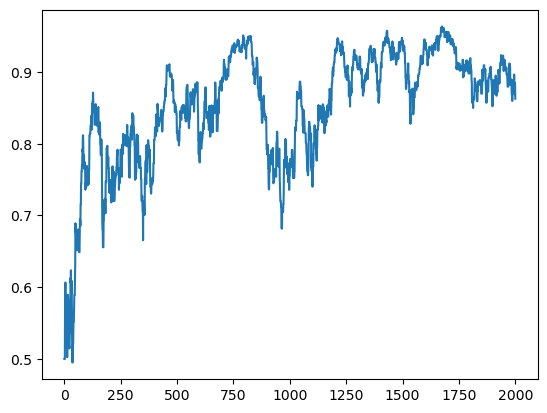

In [142]:
timesteps = np.arange(2001)
plt.plot(timesteps,rho_chain)

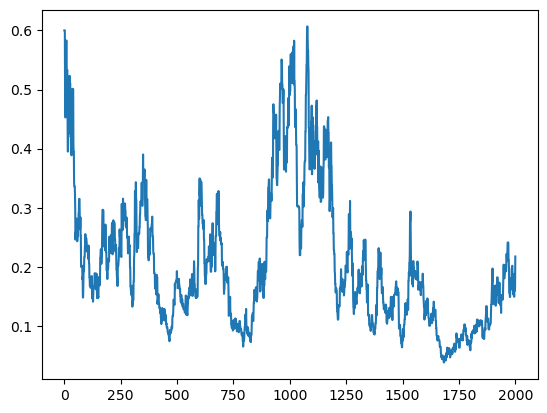

In [143]:
plt.plot(timesteps,sigma2_chain)

(array([ 23.,  27.,  41.,  82.,  99., 112.,  93.,  95.,  85.,  91., 127.,
        128.,  93.,  81.,  73.,  59.,  75.,  45.,  60.,  38.,  32.,  42.,
         26.,  29.,  27.,  23.,  27.,  20.,  18.,  20.,  16.,  15.,  22.,
         12.,  19.,  18.,  11.,   8.,  11.,   7.,  16.,  14.,   6.,   4.,
          7.,   9.,   3.,   6.,   1.,   5.]),
 array([0.03849736, 0.0498584 , 0.06121943, 0.07258047, 0.0839415 ,
        0.09530254, 0.10666357, 0.11802461, 0.12938564, 0.14074668,
        0.15210771, 0.16346875, 0.17482978, 0.18619082, 0.19755185,
        0.20891289, 0.22027392, 0.23163496, 0.24299599, 0.25435703,
        0.26571806, 0.2770791 , 0.28844013, 0.29980117, 0.3111622 ,
        0.32252324, 0.33388428, 0.34524531, 0.35660635, 0.36796738,
        0.37932842, 0.39068945, 0.40205049, 0.41341152, 0.42477256,
        0.43613359, 0.44749463, 0.45885566, 0.4702167 , 0.48157773,
        0.49293877, 0.5042998 , 0.51566084, 0.52702187, 0.53838291,
        0.54974394, 0.56110498, 0.57246601, 0.

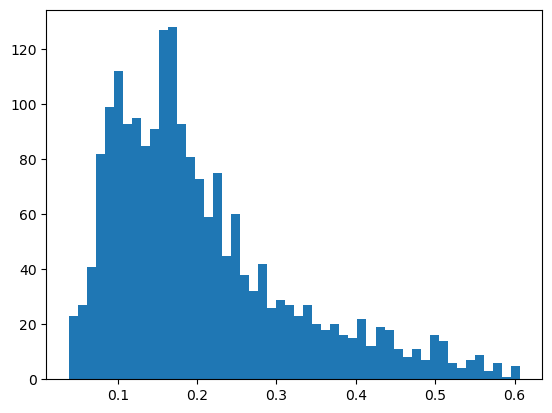

In [146]:
plt.hist(sigma2_chain,bins=50)

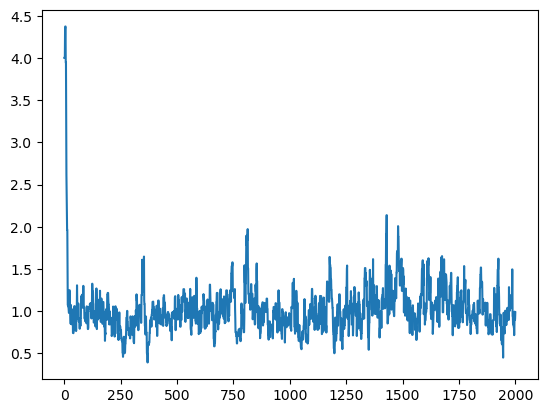

In [144]:
plt.plot(timesteps,beta2_chain)

In [ ]:
rho_chain, sigma2_chain, beta2_chain = particle_mcmc_v2(observations,2000,0.5,0.5,0.2)

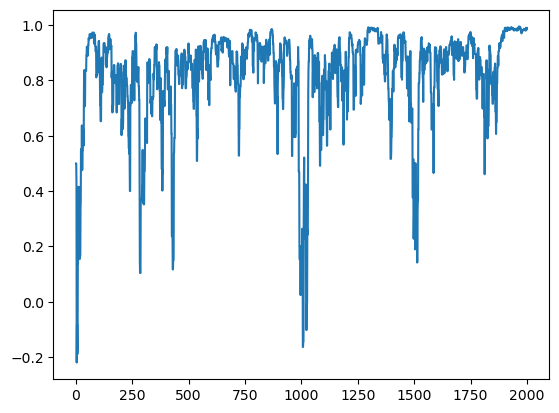

In [126]:
timesteps = np.arange(2001)
plt.plot(timesteps,rho_chain)

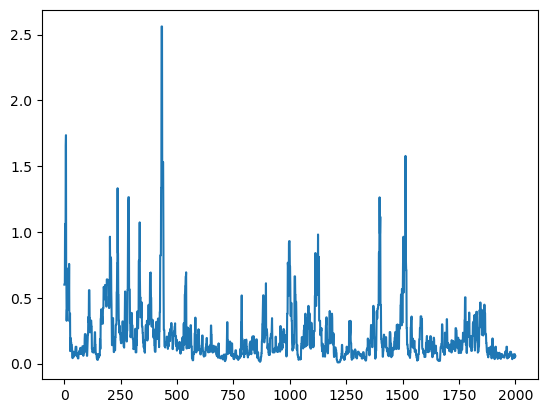

In [127]:
plt.plot(timesteps,sigma2_chain)

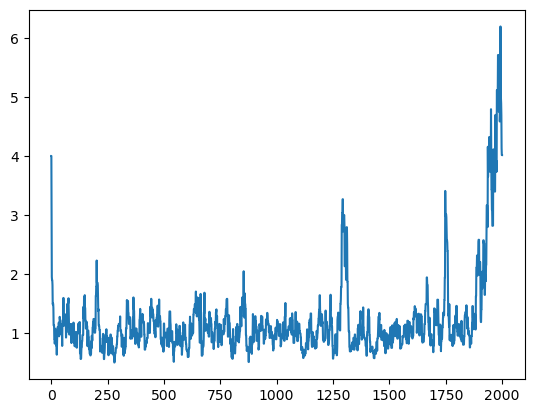

In [128]:
plt.plot(timesteps,beta2_chain)